In [33]:
import warnings
warnings.filterwarnings("ignore")

In [34]:
!pip install rasterio

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from PIL import Image
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models
import seaborn as sns

In [36]:
IMAGE_DIR = "/kaggle/input/harmonized-sentinel-landsat-water-dataset/data/images"
LABEL_DIR = "/kaggle/input/harmonized-sentinel-landsat-water-dataset/data/labels"

Image shape: (12, 128, 128)
Label shape: (128, 128)


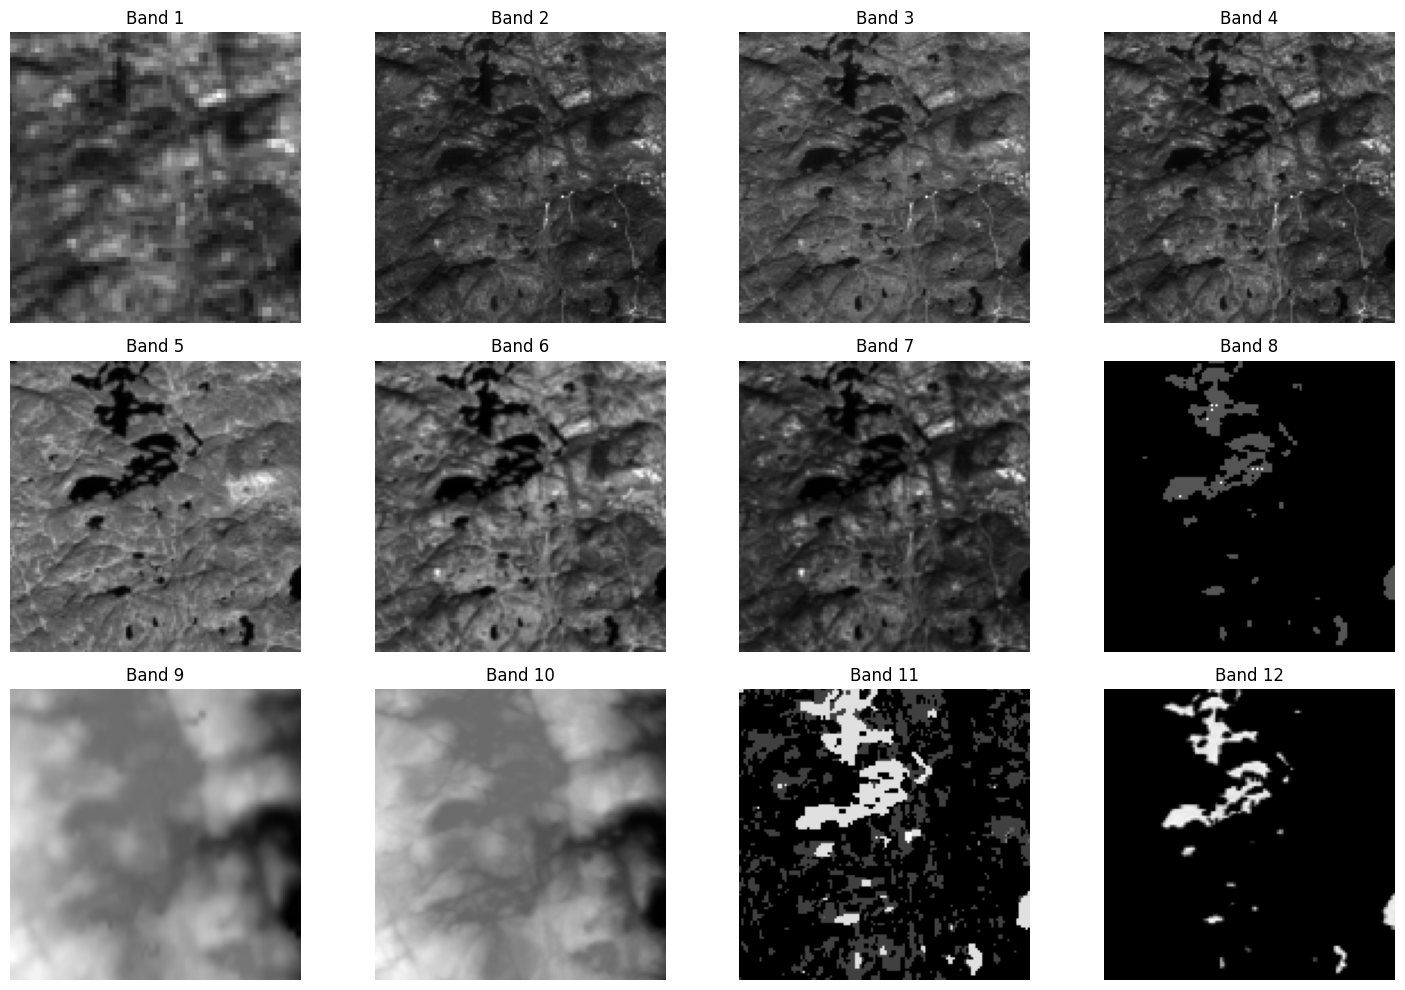

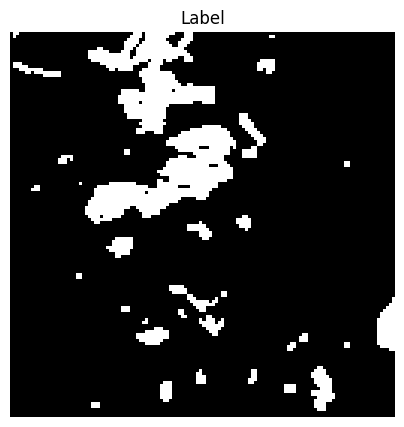

In [37]:
# Get first image and label file
image_files = sorted(os.listdir(IMAGE_DIR))
label_files = sorted(os.listdir(LABEL_DIR))

image_path = os.path.join(IMAGE_DIR, image_files[0])
label_path = os.path.join(LABEL_DIR, label_files[0])

# Read multispectral TIFF image
with rasterio.open(image_path) as src:
    image = src.read()  # Shape: (bands, height, width)

# Read label image
label = np.array(Image.open(label_path))

print("Image shape:", image.shape)  # (bands, H, W)
print("Label shape:", label.shape)

num_bands = image.shape[0]

# Create subplot grid for bands visualization
fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.flatten()

for i in range(num_bands):
    band = image[i]

    # Normalize band for visualization only
    band_min = band.min()
    band_max = band.max()
    
    if band_max != band_min:
        band_vis = (band - band_min) / (band_max - band_min)
    else:
        band_vis = band  # Avoid division by zero

    axes[i].imshow(band_vis, cmap="gray")
    axes[i].set_title(f"Band {i+1}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

# Visualize label
plt.figure(figsize=(5, 5))
plt.imshow(label, cmap="gray")
plt.title("Label")
plt.axis("off")
plt.show()

In [38]:
import os

image_files = set([f.replace(".tif", "") for f in os.listdir(IMAGE_DIR)])
label_files = set([f.replace(".png", "") for f in os.listdir(LABEL_DIR)])

print("Images count:", len(image_files))
print("Labels count:", len(label_files))

print("Labels without images:")
print(label_files - image_files)

print("Images without labels:")
print(image_files - label_files)


Images count: 306
Labels count: 456
Labels without images:
{'88_157', '105_148', '129_177', '95_221', '55_219', '38_68', '144_235', '48_12', '8_73', '14_135', '72_205', '51_91', '120_305', '96_154', '127_54', '104_20', '86_288', '67_156', '32_11', '59_132', '143_183', '37_118', '58_114', '76_92', '28_2', '135_56', '60_245', '97_130', '52_160', '46_55', '122_257', '74_65', '16_229', '29_186', '87_182', '147_213', '118_125', '47_15', '108_236', '63_17', '4_300', '130_256', '89_228', '138_39', '3_74', '11_116', '34_239', '7_146', '20_283', '139_108', '22_16', '19_293', '42_281', '10_244', '111_121', '80_124', '13_234', '93_217', '131_185', '54_51', '31_196', '45_158', '40_277', '148_297', '83_131', '12_286', '82_100', '121_142', '17_60', '64_86', '50_263', '100_184', '36_240', '94_119', '113_44', '136_301', '78_246', '41_77', '75_52', '1_226', '81_9', '24_111', '117_97', '106_267', '69_18', '112_78', '33_134', '137_140', '149_166', '146_84', '128_294', '30_143', '91_102', '25_172', '53_43

In [39]:
def load_data(image_dir, label_dir):
    images = []
    masks = []
    
    image_files = sorted(os.listdir(image_dir))
    
    for file in image_files:
        if file.endswith(".tif"):
            image_path = os.path.join(image_dir, file)
            label_path = os.path.join(label_dir, file.replace(".tif", ".png"))
            
            # Read multispectral image (12 bands)
            with rasterio.open(image_path) as src:
                image = src.read()  # (bands, H, W)
                image = np.transpose(image, (1, 2, 0))  # (H, W, bands)
            
            # Read mask
            mask = Image.open(label_path)
            mask = np.array(mask)
            
            # Ensure binary
            mask = (mask > 0).astype(np.float32)
            mask = np.expand_dims(mask, axis=-1)
            
            images.append(image)
            masks.append(mask)
    
    return np.array(images), np.array(masks)

In [40]:
X, y = load_data(IMAGE_DIR, LABEL_DIR)
print("Data shape:", X.shape, y.shape)


Data shape: (306, 128, 128, 12) (306, 128, 128, 1)


In [41]:
print(np.unique(y))


[0. 1.]


In [42]:
water_pixels = np.sum(y)
total_pixels = np.prod(y.shape)

print("Water percentage:", water_pixels / total_pixels)

Water percentage: 0.2597528594771242


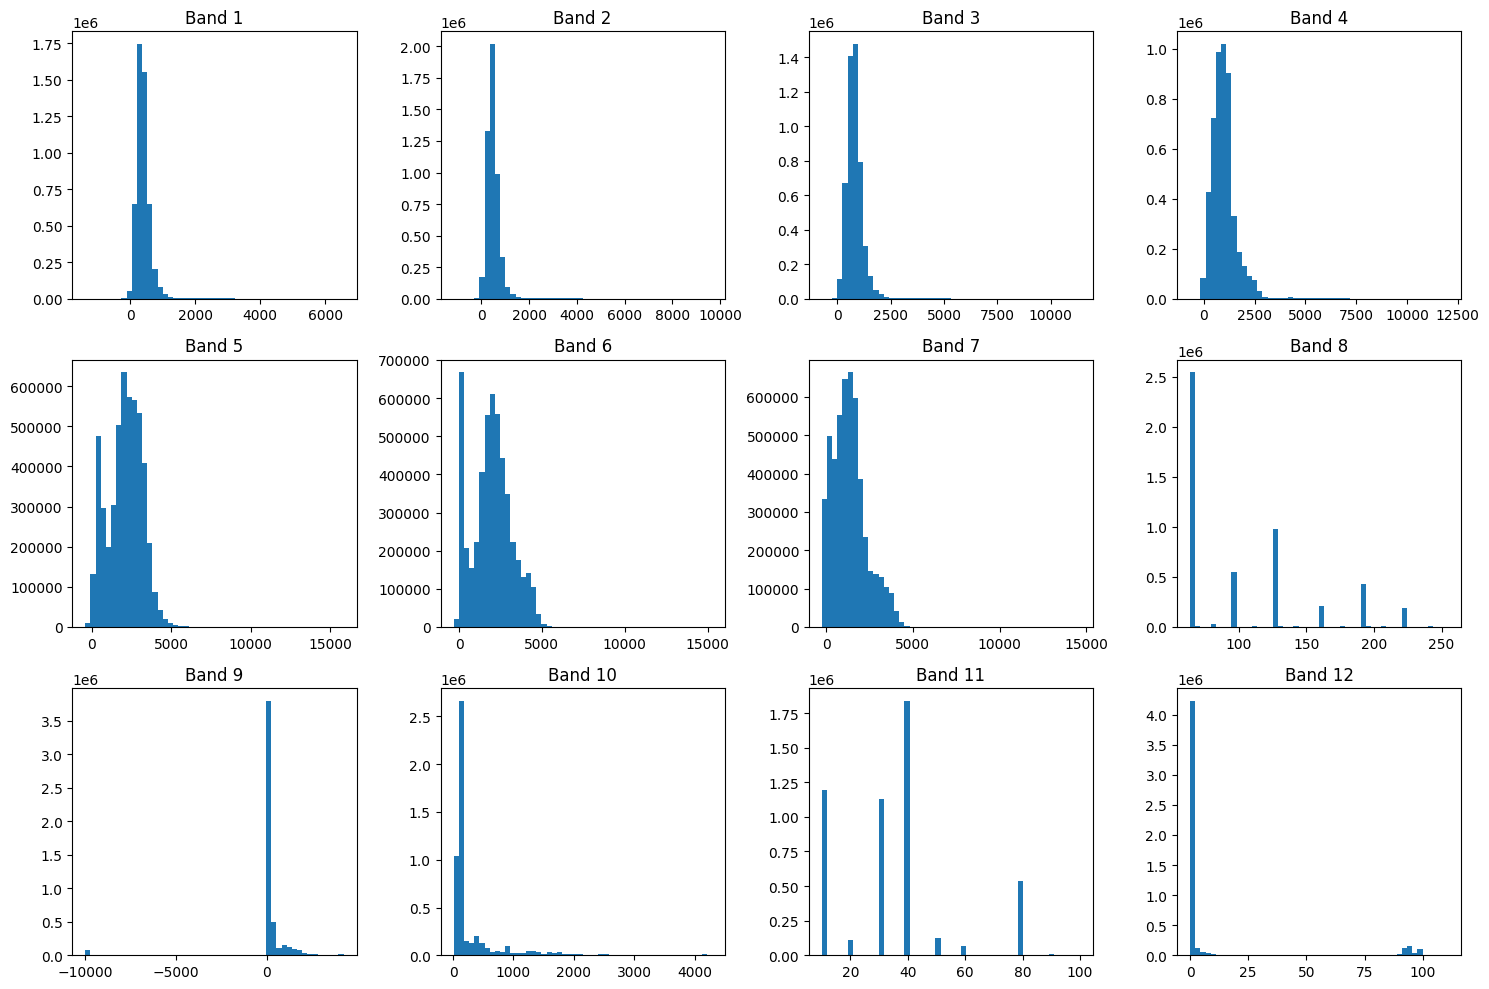

In [43]:
import matplotlib.pyplot as plt

def plot_band_histograms(X):
    fig, axes = plt.subplots(3, 4, figsize=(15, 10))
    axes = axes.flatten()
    
    for b in range(12):
        band_values = X[..., b].flatten()
        
        axes[b].hist(band_values, bins=50)
        axes[b].set_title(f'Band {b+1}')
    
    plt.tight_layout()
    plt.show()

plot_band_histograms(X)

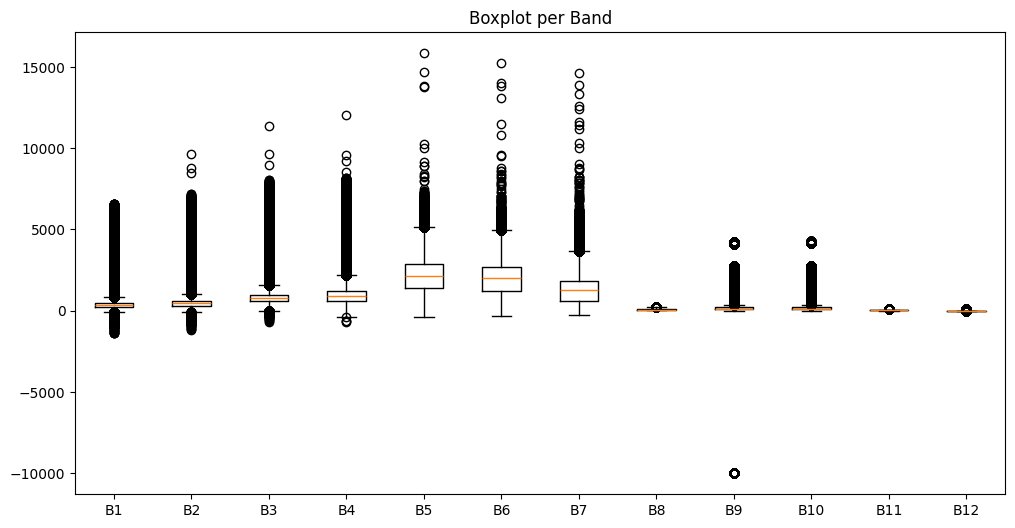

In [44]:
import numpy as np

def plot_boxplots(X):
    data = [X[..., b].flatten() for b in range(12)]
    
    plt.figure(figsize=(12,6))
    plt.boxplot(data, showfliers=True)
    plt.xticks(range(1,13), [f'B{i}' for i in range(1,13)])
    plt.title("Boxplot per Band")
    plt.show()

plot_boxplots(X)

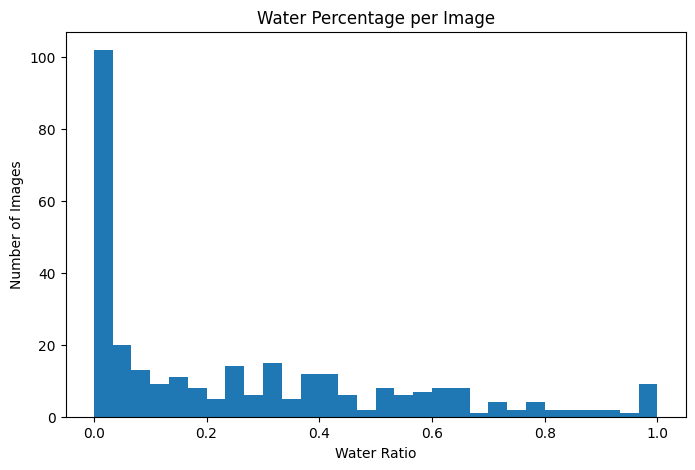

In [45]:
water_ratio_per_image = []

for i in range(len(y)):
    ratio = np.mean(y[i])
    water_ratio_per_image.append(ratio)

plt.figure(figsize=(8,5))
plt.hist(water_ratio_per_image, bins=30)
plt.title("Water Percentage per Image")
plt.xlabel("Water Ratio")
plt.ylabel("Number of Images")
plt.show()

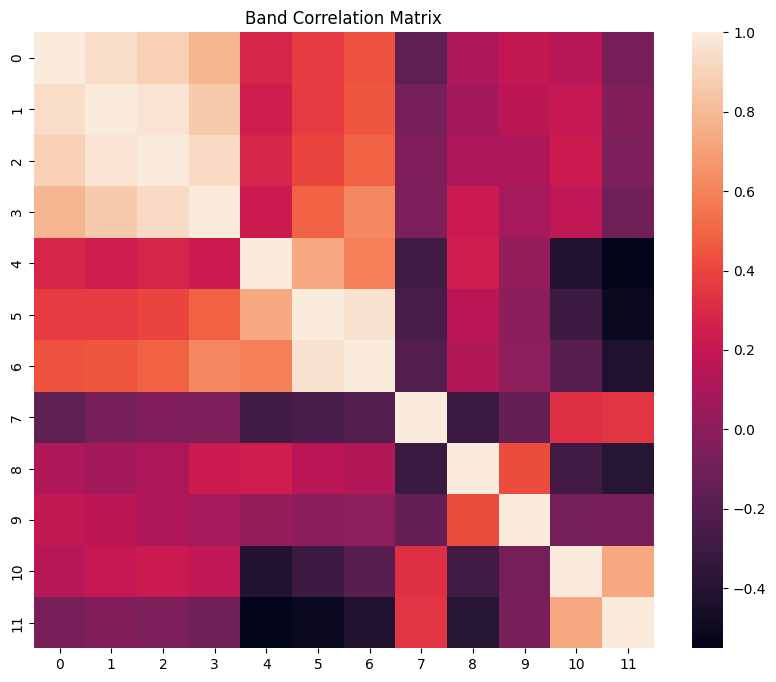

In [46]:
import seaborn as sns

X_flat = X.reshape(-1, 12)

corr_matrix = np.corrcoef(X_flat, rowvar=False)

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=False)
plt.title("Band Correlation Matrix")
plt.show()

In [47]:
# Number of test samples
test_size = 10  

# Split last 10 samples for testing
X_test = X[-test_size:]
y_test = y[-test_size:]

# Remaining data for train + validation
X_rest = X[:-test_size]
y_rest = y[:-test_size]

# Split remaining data: 80% train, 20% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_rest,
    y_rest,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (236, 128, 128, 12)
Validation: (60, 128, 128, 12)
Test: (10, 128, 128, 12)


In [51]:

# Standardization (Z-score) based on training data

means = X_train.mean(axis=(0,1,2))
stds  = X_train.std(axis=(0,1,2))

def normalize(X, means, stds):
    return (X - means) / (stds + 1e-8)

# Apply normalization
X_train = normalize(X_train, means, stds)
X_val   = normalize(X_val, means, stds)
X_test  = normalize(X_test, means, stds)

print("After Z-score normalization:")
print("Min:", X_train.min(), "Max:", X_train.max())
print("Mean per band:", X_train.mean(axis=(0,1,2)))

After Z-score normalization:
Min: -6.8031522356367065 Max: 27.786927344438237
Mean per band: [ 9.10964025e-15 -1.69013193e-13 -1.86234522e-14  4.23604135e-14
 -3.20653323e-14 -1.78238921e-15 -2.97798913e-15  3.41677584e-13
  3.32378125e-13  1.15539738e-14  3.97043309e-13 -7.08508623e-13]


In [52]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

BATCH_SIZE = 16

# Augmentation parameters
data_gen_args = dict(
    horizontal_flip=True,
    vertical_flip=True,
    rotation_range=90
)

# Image & mask generators
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen  = ImageDataGenerator(**data_gen_args)

# Fit generators on training data (required by Keras)
image_datagen.fit(X_train, augment=True, seed=42)
mask_datagen.fit(y_train, augment=True, seed=42)

# Combine image and mask into one generator
def train_gen(image_gen, mask_gen):
    while True:
        X_batch = next(image_gen)
        y_batch = next(mask_gen)
        yield X_batch, y_batch

# Generators for training
image_generator = image_datagen.flow(
    X_train,
    batch_size=BATCH_SIZE,
    seed=42
)
mask_generator = mask_datagen.flow(
    y_train,
    batch_size=BATCH_SIZE,
    seed=42
)

train_generator = train_gen(image_generator, mask_generator)
steps_per_epoch = len(X_train) // BATCH_SIZE

print("Steps per epoch:", steps_per_epoch)

Steps per epoch: 14


In [53]:
IMG_HEIGHT = 128
IMG_WIDTH = 128
CHANNELS = 12
BATCH_SIZE = 16
EPOCHS = 50 

In [54]:
# U-Net Model
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    return x

def build_unet(input_shape):
    inputs = layers.Input(shape=input_shape)
    
    # Encoder
    c1 = conv_block(inputs, 64)
    p1 = layers.MaxPooling2D()(c1)
    
    c2 = conv_block(p1, 128)
    p2 = layers.MaxPooling2D()(c2)
    
    c3 = conv_block(p2, 256)
    p3 = layers.MaxPooling2D()(c3)
    
    c4 = conv_block(p3, 512)
    p4 = layers.MaxPooling2D()(c4)
    
    # Bottleneck
    bn = conv_block(p4, 1024)
    
    # Decoder
    u1 = layers.Conv2DTranspose(512, 2, strides=2, padding="same")(bn)
    u1 = layers.concatenate([u1, c4])
    c5 = conv_block(u1, 512)
    
    u2 = layers.Conv2DTranspose(256, 2, strides=2, padding="same")(c5)
    u2 = layers.concatenate([u2, c3])
    c6 = conv_block(u2, 256)
    
    u3 = layers.Conv2DTranspose(128, 2, strides=2, padding="same")(c6)
    u3 = layers.concatenate([u3, c2])
    c7 = conv_block(u3, 128)
    
    u4 = layers.Conv2DTranspose(64, 2, strides=2, padding="same")(c7)
    u4 = layers.concatenate([u4, c1])
    c8 = conv_block(u4, 64)
    
    outputs = layers.Conv2D(1, 1, activation="sigmoid")(c8)
    
    model = models.Model(inputs, outputs)
    return model

model = build_unet((IMG_HEIGHT, IMG_WIDTH, CHANNELS))

I0000 00:00:1771621881.023679      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [55]:
def tf_iou(y_true, y_pred):
    """
    Compute Intersection over Union (IoU) for binary masks.
    """
    y_pred_bin = tf.cast(y_pred > 0.5, tf.float32)
    intersection = tf.reduce_sum(y_true * y_pred_bin)
    union = tf.reduce_sum(y_true) + tf.reduce_sum(y_pred_bin) - intersection
    return intersection / (union + 1e-7)

In [56]:
# Compile the U-Net model

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[tf_iou]  # Monitor IoU during training
)


In [57]:
# Early stopping based on validation IoU
# =========================
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_tf_iou',  # Monitor IoU on validation set
    patience=10,
    mode='max',
    restore_best_weights=True
)

In [58]:
history = model.fit(
    train_generator,
    validation_data=(X_val, y_val),
    steps_per_epoch=steps_per_epoch,
    epochs=EPOCHS,
    callbacks=[early_stop]
)


Epoch 1/50


I0000 00:00:1771622158.368273     316 service.cc:152] XLA service 0x7b14c8002e30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771622158.368330     316 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1771622160.431840     316 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/14 ━━━━━━━━━━━━━━━━━━━━ 6:31 30s/step - loss: 1.0672 - tf_iou: 0.1065

I0000 00:00:1771622178.121126     316 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 235ms/step - loss: 0.5529 - tf_iou: 0.4617

2026-02-20 21:16:35.378131: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 21:16:35.617177: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


14/14 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - loss: 0.5419 - tf_iou: 0.4704 - val_loss: 452.8706 - val_tf_iou: 0.2552
Epoch 2/50


2026-02-20 21:16:42.850670: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-02-20 21:16:43.085198: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


14/14 ━━━━━━━━━━━━━━━━━━━━ 20s 216ms/step - loss: 0.2676 - tf_iou: 0.6924 - val_loss: 107.2512 - val_tf_iou: 0.2351
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 241ms/step - loss: 0.2620 - tf_iou: 0.6388 - val_loss: 14.4058 - val_tf_iou: 0.0299
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - loss: 0.2292 - tf_iou: 0.7114 - val_loss: 5.4452 - val_tf_iou: 0.2296
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 250ms/step - loss: 0.2806 - tf_iou: 0.6667 - val_loss: 3.4427 - val_tf_iou: 0.2891
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step - loss: 0.2276 - tf_iou: 0.7080 - val_loss: 3.2862 - val_tf_iou: 0.2855
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 257ms/step - loss: 0.2492 - tf_iou: 0.6740 - val_loss: 2.5406 - val_tf_iou: 0.4188
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 235ms/step - loss: 0.2069 - tf_iou: 0.7141 - val_loss: 14.5481 - val_tf_iou: 0.2950
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 3s 250ms/step - loss: 0.2182 - tf_iou: 0.6747 - val_loss: 0.7594 - val_tf_iou: 0.4053
Epoch 10/50
14

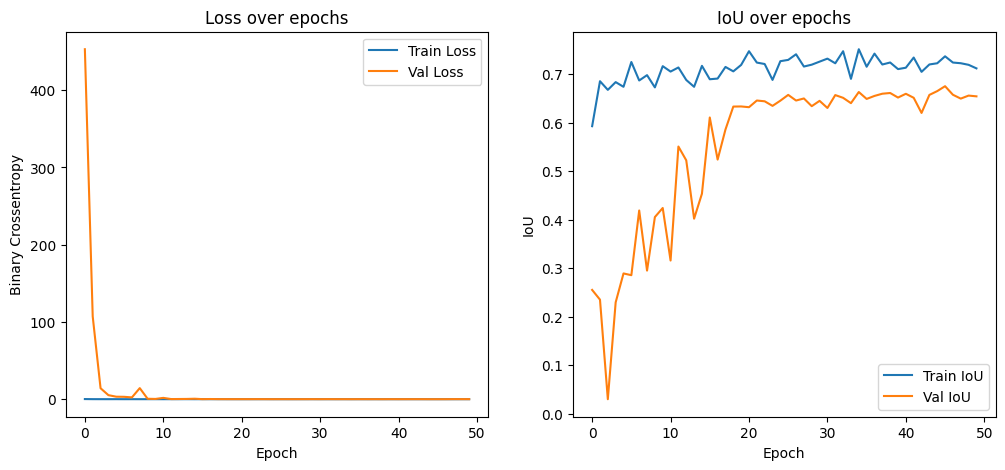

In [59]:
plt.figure(figsize=(12,5))

# Loss curve
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epoch')
plt.ylabel('Binary Crossentropy')
plt.legend()

# IoU curve
plt.subplot(1,2,2)
plt.plot(history.history['tf_iou'], label='Train IoU')
plt.plot(history.history['val_tf_iou'], label='Val IoU')
plt.title('IoU over epochs')
plt.xlabel('Epoch')
plt.ylabel('IoU')
plt.legend()

plt.show()

In [62]:
# Compute Precision, Recall, F1-score on the test set

from sklearn.metrics import precision_score, recall_score, f1_score

# Predict on test set
y_pred = model.predict(X_test)

# Convert probabilities to binary masks
y_pred_bin = (y_pred > 0.5).astype(np.uint8).flatten()
y_true_bin = y_test.flatten()

# Calculate metrics
precision = precision_score(y_true_bin, y_pred_bin)
recall = recall_score(y_true_bin, y_pred_bin)
f1 = f1_score(y_true_bin, y_pred_bin)

# Calculate IoU for the whole test set
intersection = np.sum(y_true_bin * y_pred_bin)
union = np.sum(y_true_bin) + np.sum(y_pred_bin) - intersection
iou = intersection / (union + 1e-7)

print(f"Test Precision: {precision:.4f}")
print(f"Test Recall: {recall:.4f}")
print(f"Test F1-score: {f1:.4f}")
print(f"Test IoU: {iou:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
Test Precision: 0.9396
Test Recall: 0.6459
Test F1-score: 0.7656
Test IoU: 0.6202


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.2420874553951782..11.312392992240346].


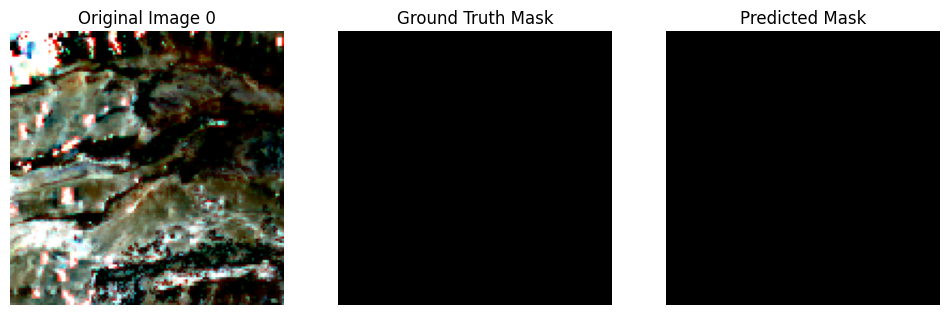

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9041695977257931..4.345429440280328].


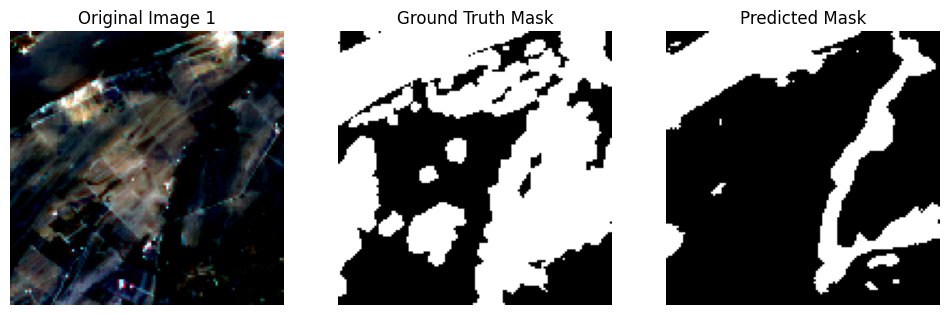

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.3459708090005464..8.220064933326379].


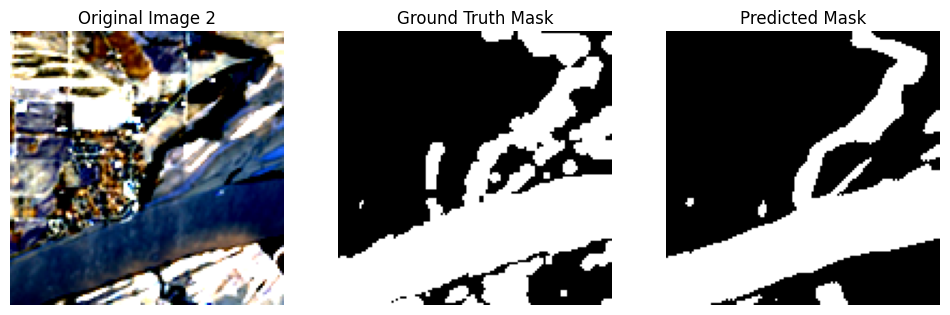

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-5.502152565024883..5.591108993365198].


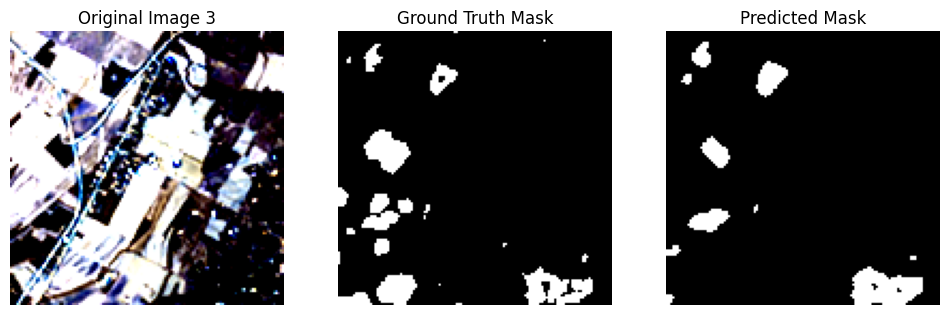

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.954799534695707..14.05915930123764].


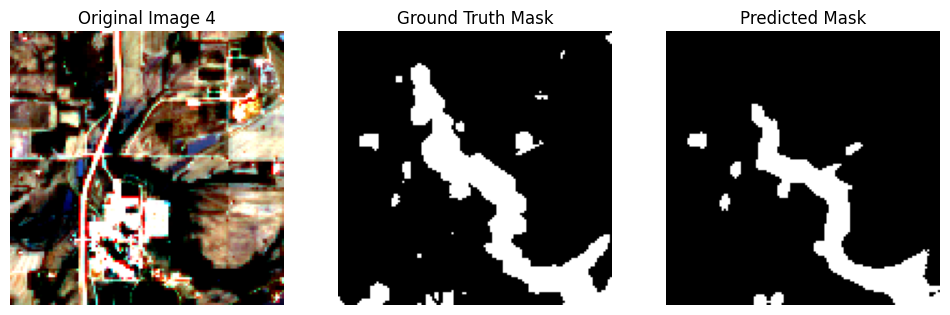

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9738922704579631..14.125857820882166].


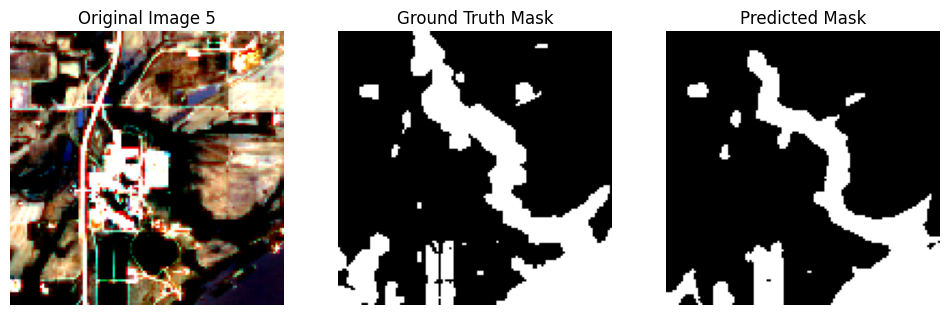

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6183080313377705..0.7062505121687559].


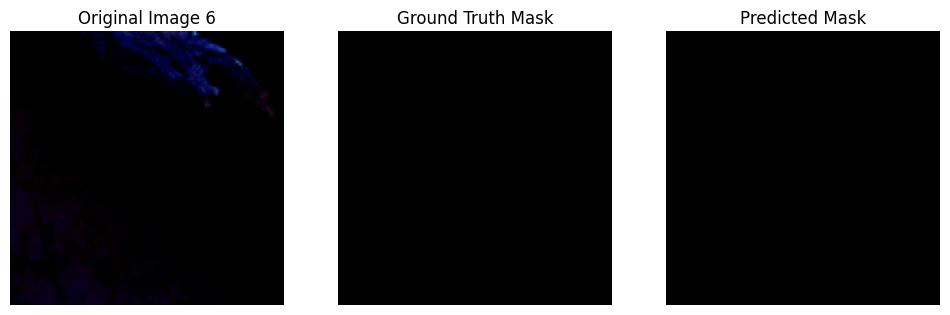

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.477481140639301..13.91060350748392].


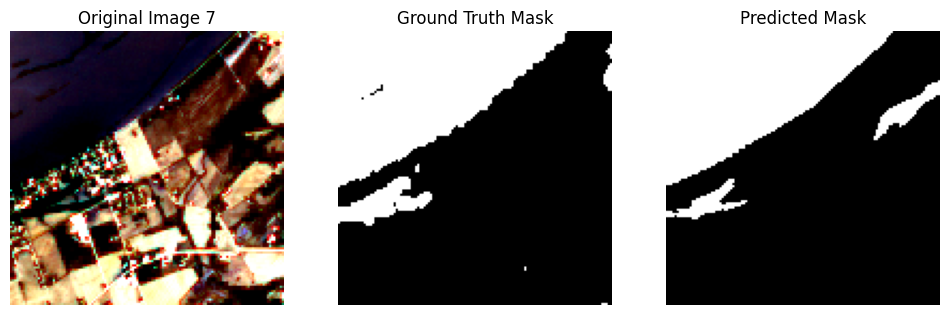

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6779548661429915..2.6264266839873214].


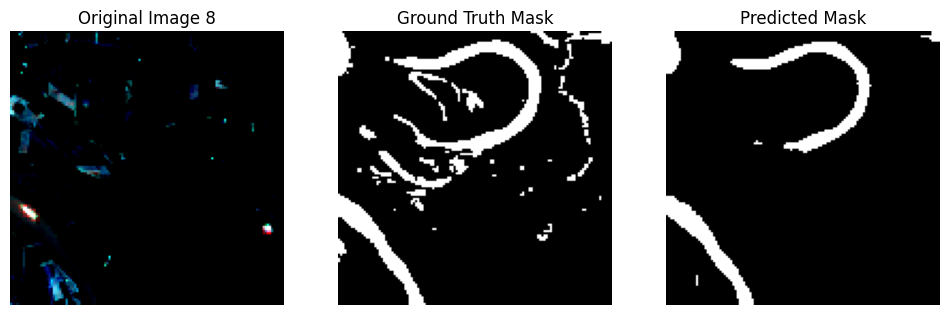

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9515171643414986..2.693125203631847].


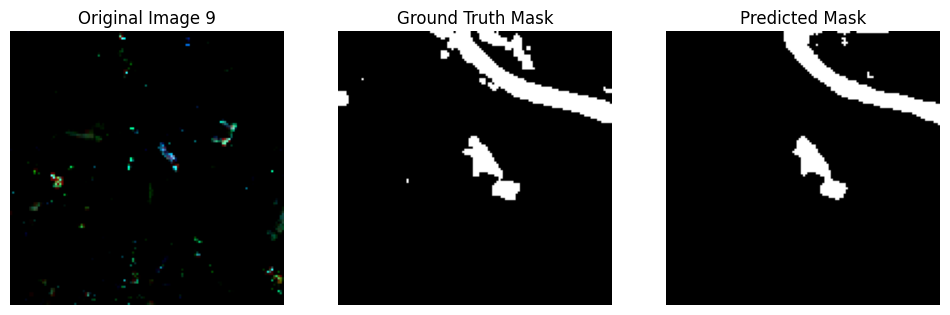

In [63]:
import matplotlib.pyplot as plt
import numpy as np

for idx in range(len(X_test)):
    img = X_test[idx]
    true_mask = y_test[idx][..., 0]
    
    # Predict mask
    pred_mask = (model.predict(img[np.newaxis, ...])[0, ..., 0] > 0.5).astype(np.uint8)
    
    # Plot the results
    plt.figure(figsize=(12,4))
    
    # Original image (RGB approximation: first 3 bands)
    plt.subplot(1,3,1)
    plt.imshow(img[..., :3])
    plt.title(f"Original Image {idx}")
    plt.axis("off")
    
    # Ground truth mask
    plt.subplot(1,3,2)
    plt.imshow(true_mask, cmap="gray")
    plt.title("Ground Truth Mask")
    plt.axis("off")
    
    # Predicted mask
    plt.subplot(1,3,3)
    plt.imshow(pred_mask, cmap="gray")
    plt.title("Predicted Mask")
    plt.axis("off")
    
    plt.show()